# Machine Learning 2025W — Exercise 1  
### Dataset Description and Exploration (breast cancer)

**Group Members:**  
- Full Name 1  
- Full Name 2  
- Full Name 3  

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
import ssl
import certifi
import itertools
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree



## Load data

In [ ]:
file_path = '../datasets/184-702-tu-ml-2025w-breast-cancer/'
df= pd.read_csv(file_path+ "breast-cancer-diagnostic.shuf.lrn.csv")
df_kaggle_test= pd.read_csv(file_path+ "breast-cancer-diagnostic.shuf.tes.csv")
df=df.set_index("ID")
df.head()


In [ ]:
df.shape

### Basic Information

In [ ]:
df.info()
df.describe()
df.isna().sum()

In [ ]:
df_kaggle_test.info()
df_kaggle_test.describe()
df_kaggle_test.isna().sum()

### Target Variable Analysis

In [ ]:
target_col = 'class' 
sns.countplot(x=target_col, data=df)
plt.title('Breast cancer class - Training set')
plt.xlabel('Breast cancer class')
plt.show()

### Feature Exploration

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(24, 16))
plt.suptitle("Numeric Feature Distributions")
plt.show()

# There are no categorical variables

# Preprocessing


## Target varaiable 

Since most models require numerical input, we will map the class to 0(no cancer) and 1(cancer).

In [ ]:
def target_to_num(x):
    if x==False:
        return 0
    else:
        return 1
    
df["class"]= df["class"].apply(target_to_num)

sns.countplot(x=target_col, data=df)
plt.title('Breast cancer class - Training set')
plt.xlabel('Breast cancer class')
plt.show()

## Input variables

### Check for outliers

In [ ]:
# Select numeric columns (excluding target variable)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'class' in numeric_cols:
    numeric_cols.remove('class') # class not included

print(f"Number of numeric columns to check: {len(numeric_cols)}")

# Define and run outlier detection function
def detect_outliers_iqr(df, columns):
    
    outlier_info = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100
        
        outlier_info[col] = {
            'count': outlier_count,
            'percentage': outlier_percentage,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'min': df[col].min(),
            'max': df[col].max(),
            'mean': df[col].mean(),
            'std': df[col].std()
        }
    
    return pd.DataFrame(outlier_info).T.sort_values('percentage', ascending=False)

# Run outlier detection
outlier_summary = detect_outliers_iqr(df, numeric_cols)
print("\nOutlier Summary:")
print(outlier_summary.head(10))

# Create the boxplots
n_cols = 5
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, ax=axes[idx])
    outlier_pct = outlier_summary.loc[col, 'percentage']
    axes[idx].set_title(f'{col}', fontsize=9)
    axes[idx].tick_params(labelsize=8)


plt.tight_layout()
plt.show()

To decide how to handle the outliers, we first need to consider the background of the data. In this case it is medical data, where outliers can be very important for the diagnosis. Therefore, we will look if the outliers are data errors or just extreme values that should be kept in the dataset. 
In this case we flag data points as outlier if they are lower then Q1 - 1.5 * IQR or higher then Q3 + 1.5 * IQR.
In this data, the columns : areaStdErr, smoothnessStdErr, radiusStdErr, perimeterStdErr, fractalDimensionWorst, concavityStdErr, symmetryStdErr, areaMean, areaWorst, and symmetryWorst show outliers with a percentage of 11%-3 %.
We further looked at the plots and the min and max values of these columns and found that the outliers are not data errors but extreme values. Therefore, we will keep them in the dataset.

### Handle missing values

In [ ]:
print(df.isnull().sum())
print((df.astype(str)=="?").any())
print((df.astype(str)=="nan").any())

WE can see that there are no missing values in the dataset. This also alignes with the discriotion of the datatset provided.

In [ ]:
print(df_kaggle_test.isnull().sum())
print((df_kaggle_test.astype(str)=="?").any())
print((df_kaggle_test.astype(str)=="nan").any())

Also no missing values in  the test dataset.

## Split training data into train and test sets

In [ ]:
X = df.drop("class", axis=1)  # features
y = df["class"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% of data for testing
    random_state=42,     # ensures reproducibility
    stratify=y           # keeps same class proportions in train/test
)

X_train.head()

## Scale data

In [ ]:
#Scale training and test data
X_train_scaled=X_train.copy()
X_test_scaled= X_test.copy()
scaler = StandardScaler()
X_train_scaled[numeric_cols]= scaler.fit_transform(X_train_scaled[numeric_cols])
X_test_scaled[numeric_cols]= scaler.fit_transform(X_test_scaled[numeric_cols])
X_test_scaled.describe()

In [ ]:
# Scale the kaggle test data
df_kaggle_test_scaled=df_kaggle_test.copy()
scaler = StandardScaler()
df_kaggle_test_scaled[numeric_cols]= scaler.fit_transform(df_kaggle_test_scaled[numeric_cols])

df_kaggle_test_scaled.describe()

In [ ]:
print(numeric_cols)

# Model Training and Evaluation

We train three classifiers — Decision Tree, KNN, and Naive Bayes — and check how well they predict loan grades.

## Decision Tree Classifier

First we train decision tree clasifiers on multiple combinations of Hyperparameters (the result will be displayed as an dataframe) and inspect the results using specific plots 

In [ ]:

# Hyperparameter lists
max_depths = [3,5,10, None]
min_splits = [5,10, 20]
min_leafs = [3,5, 10]
criterions = ["gini", "entropy"]
weights = [None, "balanced"]

results = []

# Loop through all combinations
for depth, split, leaf, crit, weight in itertools.product(max_depths, min_splits, min_leafs, criterions, weights):
    
    clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=split,
        min_samples_leaf=leaf,
        criterion=crit,
        class_weight=weight,
        random_state=42
    )
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]  # probability for AUC
    
    results.append({
        "max_depth": depth,
        "min_samples_split": split,
        "min_samples_leaf": leaf,
        "criterion": crit,
        "class_weight": str(weight),
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average='macro'),
        "weighted_f1": f1_score(y_test, y_pred, average='weighted'),
        "auc": roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
res_df_ordered= results_df.copy()
res_df_ordered.sort_values(by="macro_f1", ascending=False, inplace=True)
res_df_ordered = res_df_ordered.set_index(["class_weight","criterion","max_depth","min_samples_split","min_samples_leaf"])
res_df_ordered= res_df_ordered.sort_index()
res_df_ordered.head(50)

In [ ]:
# Plots for visualization

## Headmap for the differnt min/max values:
leaf_values = sorted(results_df["min_samples_leaf"].unique())

# Create a single figure with 1 row and N columns (one subplot per leaf value)
fig, axes = plt.subplots(1, len(leaf_values), figsize=(6 * len(leaf_values), 4), sharey=True)

for ax, leaf in zip(axes, leaf_values):
    subset = results_df[results_df["min_samples_leaf"] == leaf]
    heatmap_data = subset.pivot_table(
        values="macro_f1",
        index="max_depth",
        columns="min_samples_split"
    )
    
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"min_samples_leaf = {leaf}")
    ax.set_xlabel("min_samples_split")
    ax.set_ylabel("max_depth")

plt.suptitle("Macro F1 by max_depth and min_samples_split for different min_samples_leaf values", y=1.05)
plt.tight_layout()
plt.show()


## Bar chart to show the effect of differnt criterions
sns.barplot(x='class_weight', y='macro_f1', hue='criterion', data=results_df)
plt.title("Effect of class_weight and criterion on Macro F1")
plt.show()

## Plot to show the influnce of weighting the classes
sns.scatterplot(x='weighted_f1', y='macro_f1', hue='class_weight', style='criterion', data=results_df)
plt.title("Weighted F1 vs Macro F1 across Decision Tree variants (class_weight)")
plt.show()



We numerically search the best model dependent on the various evaluation metrics (macro_f1, weighted_f1, accuracy, auc).:

In [ ]:
# Choose the best combination of hyper paramters model:
hyperparams = ["max_depth","min_samples_split","min_samples_leaf","criterion","class_weight"]
# Pick the row with the highest Macro F1
best_model = results_df.loc[results_df['macro_f1'].idxmax()]

print("Optimal hyperparameter combination based on Macro F1:")
print(best_model[hyperparams])

# Pick the row with the highest weighted_f1
best_model = results_df.loc[results_df['weighted_f1'].idxmax()]

print("Optimal hyperparameter combination based on weighted_f1:")
print(best_model[hyperparams])

# Pick the row with the highest accuracy
best_model = results_df.loc[results_df['accuracy'].idxmax()]

print("Optimal hyperparameter combination based on accuracy:")
print(best_model[hyperparams])

# Pick the row with the highest auc
best_model = results_df.loc[results_df['auc'].idxmax()]

print("Optimal hyperparameter combination based on auc:")
print(best_model[hyperparams])


We fit the choosen best model and look what the most importnat features are:

In [ ]:
# Fit the evaluated optical model and get the most important attributes
clf_best = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    criterion="entropy",
    class_weight="balanced",
    random_state=42
)

clf_best.fit(X_train, y_train)

# Get feature importances
importances = clf_best.feature_importances_

# Combine with feature names
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Top important features:")
print(feature_importance_df.head(10)) 

We compare the evaluation metrics for the unscaled and scaled dataset:

In [ ]:
#Resulting evaulation values for the best selected model
test_pred = clf_best.predict(X_test)

print("Classification report for the UNSCALED data: ")
print(classification_report(y_test, test_pred))


# Apply the best model on the scaled data (shoulnt make any big difference)
clf_best_scaled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    criterion="entropy",
    class_weight="balanced",
    random_state=42
)

clf_best_scaled.fit(X_train_scaled, y_train)

test_pred_scaled = clf_best_scaled.predict(X_test_scaled)

print("Classification report for the SCALED data: ")
print(classification_report(y_test, test_pred_scaled))

In [ ]:

plt.figure(figsize=(20, 10))
plot_tree(
    clf_best,
    filled=True,
    rounded=True,
    class_names=[str(cls) for cls in clf_best.classes_],
    feature_names=X_train.columns,
    fontsize=10
)
plt.title("Decision Tree (Best Model)")
plt.show()

# K-NN

## K-NN Algorithm base


In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# 1. Keep only numeric features
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. Scale them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# 3. Determine optimal k = sqrt(n)
k = int(np.sqrt(len(X_train_numeric)))
if k % 2 == 0:
    k += 1
print(f"Using k = {k}")

# 4. Train, predict, and measure runtime
start_unscaled = time.time()
knn_unscaled = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_unscaled.fit(X_train_numeric, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test_numeric)
y_prob_unscaled = knn_unscaled.predict_proba(X_test_numeric)
time_unscaled = time.time() - start_unscaled

start_scaled = time.time()
knn_scaled = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
y_prob_scaled = knn_scaled.predict_proba(X_test_scaled)
time_scaled = time.time() - start_scaled

# 5. Evaluate
def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob[:, 1])  # use probability of positive class
    }

scores_unscaled = evaluate(y_test, y_pred_unscaled, y_prob_unscaled)
scores_scaled = evaluate(y_test, y_pred_scaled, y_prob_scaled)

# 6. Display results
print("\nUnscaled performance:")
for metric, value in scores_unscaled.items():
    print(f"{metric:10}: {value:.4f}")
print(f"Runtime   : {time_unscaled:.3f} seconds")

print("\nScaled performance:")
for metric, value in scores_scaled.items():
    print(f"{metric:10}: {value:.4f}")
print(f"Runtime   : {time_scaled:.3f} seconds")


Using k = 15

Unscaled performance:
Accuracy  : 0.8772
Precision : 1.0000
Recall    : 0.6818
F1        : 0.8108
ROC AUC   : 0.9403
Runtime   : 0.016 seconds

Scaled performance:
Accuracy  : 0.9298
Precision : 0.9500
Recall    : 0.8636
F1        : 0.9048
ROC AUC   : 0.9545
Runtime   : 0.002 seconds


#### Feature selection. remove highly correlated >0.9

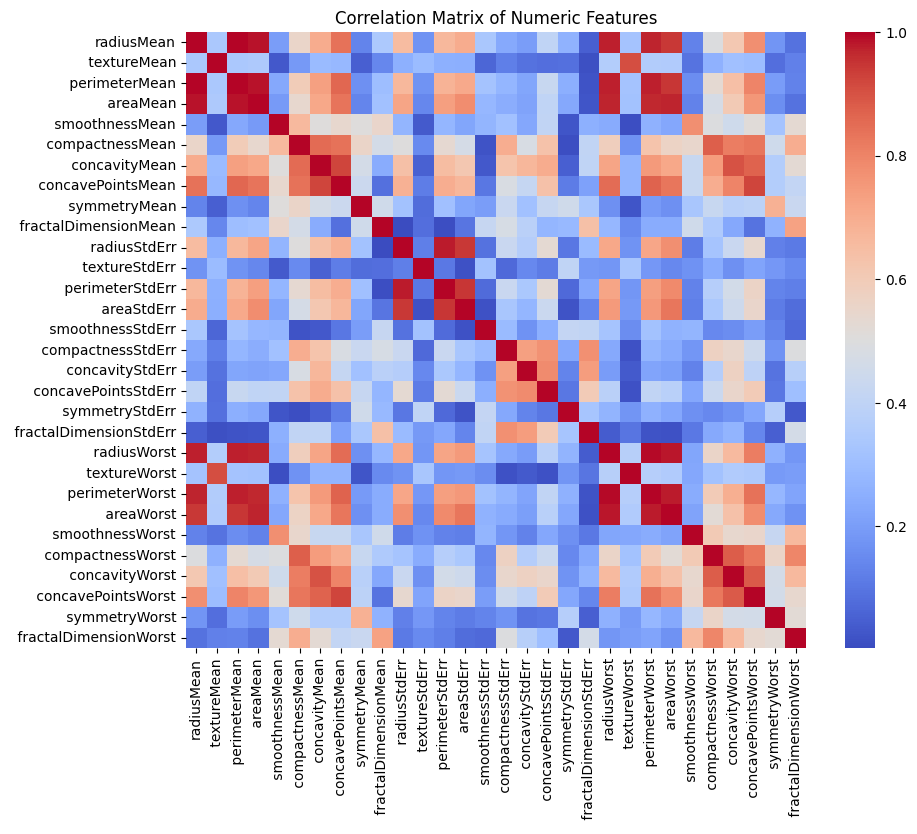

Removed features: [' perimeterMean', ' areaMean', ' concavePointsMean', ' perimeterStdErr', ' areaStdErr', ' radiusWorst', ' textureWorst', ' perimeterWorst', ' areaWorst', ' concavityWorst', ' concavePointsWorst']
Accuracy (unscaled): 0.8596
Accuracy (scaled):   0.8421


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Keep only numeric features
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. Compute correlation matrix and remove highly correlated features
corr_matrix = X_train_numeric.corr().abs()

# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop columns with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_reduced = X_train_numeric.drop(columns=to_drop)
X_test_reduced = X_test_numeric.drop(columns=to_drop, errors='ignore')

# Show correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# 3. Scale remaining features
scaler = StandardScaler()
X_train_scaled_reduced = scaler.fit_transform(X_train_reduced)
X_test_scaled_reduced = scaler.transform(X_test_reduced)

# 4. Train and compare
knn_unscaled = KNeighborsClassifier(n_neighbors=k)
knn_unscaled.fit(X_train_reduced, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test_reduced))

knn_scaled = KNeighborsClassifier(n_neighbors=k)
knn_scaled.fit(X_train_scaled_reduced, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled_reduced))

print(f"Removed features: {to_drop}")
print(f"Accuracy (unscaled): {acc_unscaled:.4f}")
print(f"Accuracy (scaled):   {acc_scaled:.4f}")


### random Subset comparison

         subset  n_features  accuracy  runtime_sec
0  1/3 features          10  0.842105     0.038787
1  2/3 features          20  0.842105     0.073783
2  All features          30  0.877193     0.025865


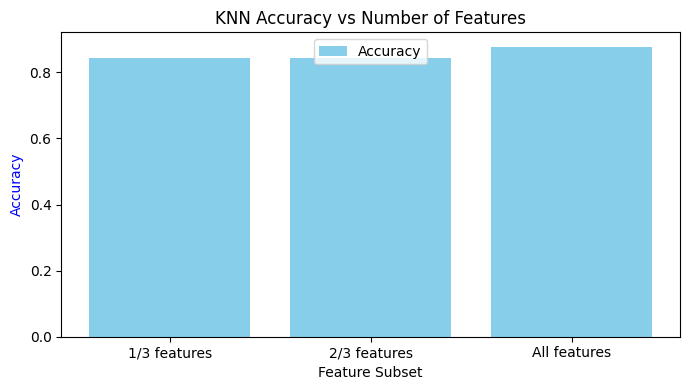

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import time
n_features = X.shape[1]
# Define feature subsets
subset_sizes = [int(n_features/3), int(2*n_features/3), n_features]
subset_labels = ['1/3 features', '2/3 features', 'All features']

# Store results
results = []

for size, label in zip(subset_sizes, subset_labels):
    # Select first N features
    X_train_sub = X_train.iloc[:, :size]
    X_test_sub = X_test.iloc[:, :size]

    knn = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree', n_jobs=-1)

    start = time.time()
    knn.fit(X_train_sub, y_train)
    y_pred = knn.predict(X_test_sub)
    runtime = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    results.append({'subset': label, 'n_features': size, 'accuracy': acc, 'runtime_sec': runtime})

# Display results
df = pd.DataFrame(results)
print(df)

# --- Visualization (Accuracy only) ---
plt.figure(figsize=(7,4))
plt.bar(df['subset'], df['accuracy'], color='skyblue', label='Accuracy')

plt.xlabel('Feature Subset')
plt.ylabel('Accuracy', color='blue')
plt.title('KNN Accuracy vs Number of Features')
plt.legend(loc='upper center')

plt.tight_layout()
plt.show()


## Best Model (Fine-tuning)


Model performance on test set:
Accuracy : 0.9298
Precision: 0.9309
Recall   : 0.9298
F1-score : 0.9291


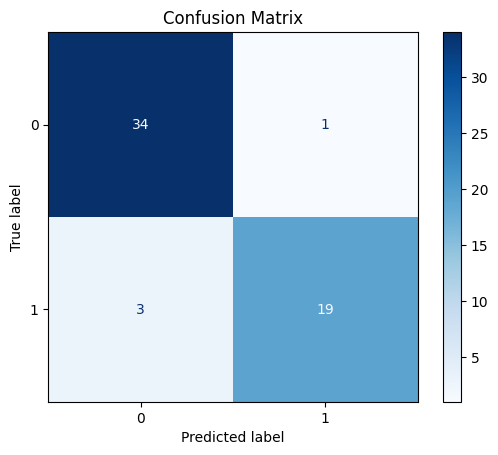


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        35
           1       0.95      0.86      0.90        22

    accuracy                           0.93        57
   macro avg       0.93      0.92      0.92        57
weighted avg       0.93      0.93      0.93        57



In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
import matplotlib.pyplot as plt

# Evaluate best model on test set
y_pred = best_knn.predict(X_test_scaled)

# If probabilities available, compute ROC AUC safely
try:
    y_prob = best_knn.predict_proba(X_test_scaled)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
except Exception:
    roc_auc = None

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print all metrics
print("\nModel performance on test set:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
if roc_auc is not None:
    print(f"ROC AUC  : {roc_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=best_knn.classes_).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# Optional full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


## Visualization

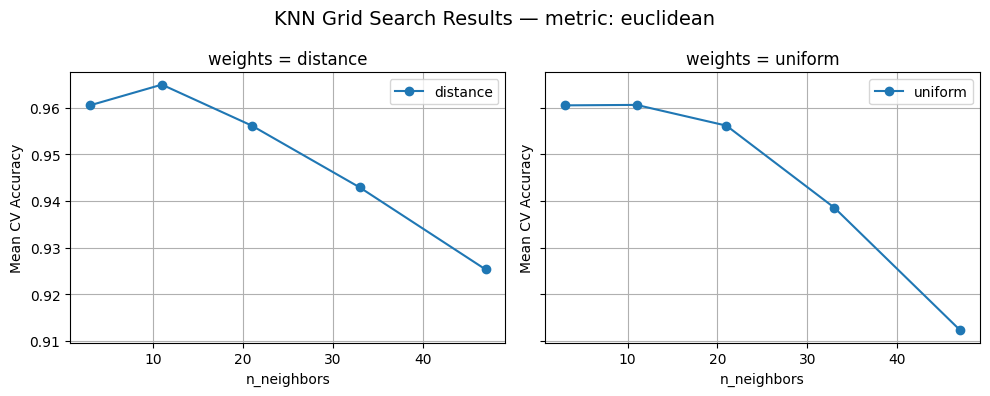

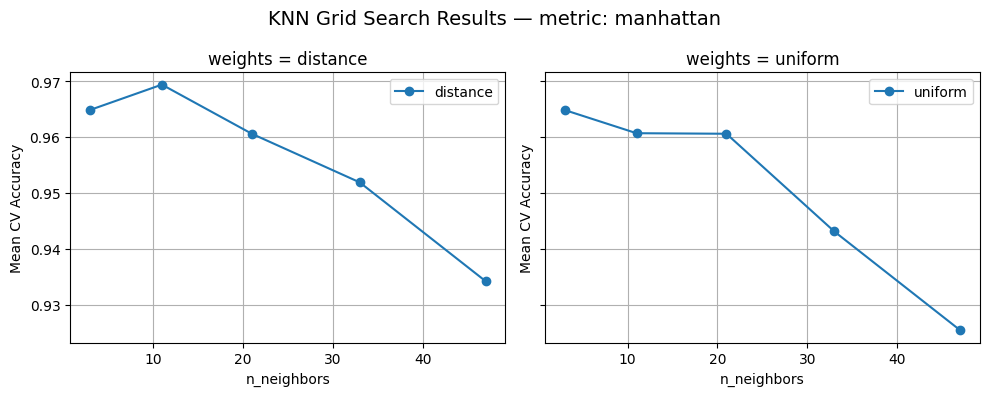

In [ ]:
# ---- Grid Search Visualization ----
results = grid.cv_results_
k_values = sorted(list(set(results['param_n_neighbors'])))
weights = sorted(list(set(results['param_weights'])))
metrics = sorted(list(set(results['param_metric'])))

for metric in metrics:
    fig, axes = plt.subplots(1, len(weights), figsize=(10, 4), sharey=True)
    fig.suptitle(f"KNN Grid Search Results — metric: {metric}", fontsize=14)

    for i, weight in enumerate(weights):
        # Collect mean CV accuracies for each k
        scores = []
        for k in k_values:
            mask = (results['param_n_neighbors'] == k) & \
                   (results['param_metric'] == metric) & \
                   (results['param_weights'] == weight)
            mean_score = np.mean(results['mean_test_score'][mask])
            scores.append(mean_score)

        axes[i].plot(k_values, scores, marker='o', label=f'{weight}')
        axes[i].set_title(f'weights = {weight}')
        axes[i].set_xlabel('n_neighbors')
        axes[i].set_ylabel('Mean CV Accuracy')
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

## Compuation time comparison

    algorithm  leaf_size  n_jobs  accuracy  runtime_sec
0       brute         10       1       1.0     0.001847
1       brute         10      -1       1.0     0.000658
2       brute         20       1       1.0     0.000547
3       brute         20      -1       1.0     0.003525
4       brute         30       1       1.0     0.003873
5       brute         30      -1       1.0     0.001381
6       brute         40       1       1.0     0.010190
7       brute         40      -1       1.0     0.000966
8       brute         50       1       1.0     0.000649
9       brute         50      -1       1.0     0.014175
10    kd_tree         10       1       1.0     0.001849
11    kd_tree         10      -1       1.0     0.014566
12    kd_tree         20       1       1.0     0.001623
13    kd_tree         20      -1       1.0     0.016709
14    kd_tree         30       1       1.0     0.001710
15    kd_tree         30      -1       1.0     0.017733
16    kd_tree         40       1       1.0     0

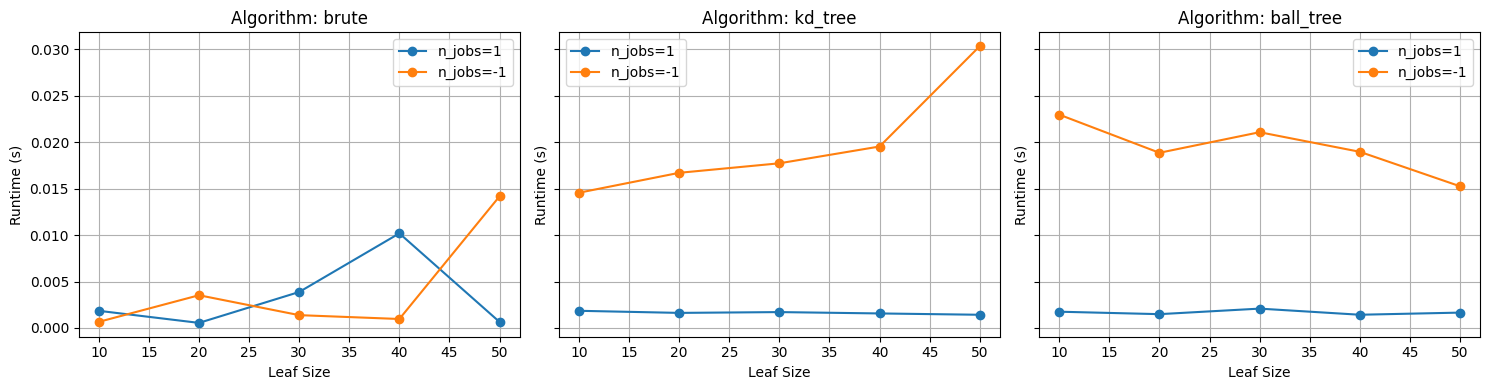

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load and preprocess data
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Parameters to compare
algorithms = ['brute', 'kd_tree', 'ball_tree']
leaf_sizes = [10, 20, 30, 40, 50]
n_jobs_values = [1, -1]  # 1 CPU vs all CPUs

# Store results
results = []

for algo in algorithms:
    for leaf in leaf_sizes:
        for n_jobs in n_jobs_values:
            knn = KNeighborsClassifier(
                n_neighbors=5,
                algorithm=algo,
                leaf_size=leaf,
                n_jobs=n_jobs
            )

            start = time.time()
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_test)
            end = time.time()

            runtime = end - start
            acc = accuracy_score(y_test, y_pred)

            results.append({
                'algorithm': algo,
                'leaf_size': leaf,
                'n_jobs': n_jobs,
                'accuracy': acc,
                'runtime_sec': runtime
            })

# Create DataFrame
df = pd.DataFrame(results)
print(df)

# --- Visualization ---
fig, axes = plt.subplots(1, len(algorithms), figsize=(15, 4), sharey=True)
for i, algo in enumerate(algorithms):
    subset = df[df['algorithm'] == algo]
    for n_jobs in n_jobs_values:
        sub = subset[subset['n_jobs'] == n_jobs]
        axes[i].plot(sub['leaf_size'], sub['runtime_sec'], marker='o', label=f'n_jobs={n_jobs}')
    axes[i].set_title(f'Algorithm: {algo}')
    axes[i].set_xlabel('Leaf Size')
    axes[i].set_ylabel('Runtime (s)')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()


## Subset k-NN

         subset  n_features  accuracy  runtime_sec
0  1/3 features           1  0.766667     0.019240
1  2/3 features           2  0.800000     0.022102
2  All features           4  1.000000     0.017319


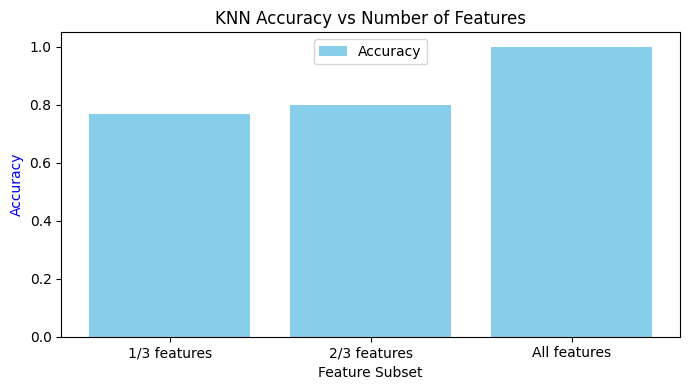

In [ ]:
n_features = X.shape[1]
# Define feature subsets
subset_sizes = [int(n_features/3), int(2*n_features/3), n_features]
subset_labels = ['1/3 features', '2/3 features', 'All features']

# Store results
results = []

for size, label in zip(subset_sizes, subset_labels):
    # Select first N features
    X_train_sub = X_train[:, :size]
    X_test_sub = X_test[:, :size]

    # Initialize KNN
    knn = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree', n_jobs=-1)

    # Measure time
    start = time.time()
    knn.fit(X_train_sub, y_train)
    y_pred = knn.predict(X_test_sub)
    runtime = time.time() - start

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results.append({'subset': label, 'n_features': size, 'accuracy': acc, 'runtime_sec': runtime})

# Display results
df = pd.DataFrame(results)
print(df)

# --- Visualization (Accuracy only) ---
plt.figure(figsize=(7,4))
plt.bar(df['subset'], df['accuracy'], color='skyblue', label='Accuracy')

plt.xlabel('Feature Subset')
plt.ylabel('Accuracy', color='blue')
plt.title('KNN Accuracy vs Number of Features')
plt.legend(loc='upper center')

plt.tight_layout()
plt.show()
